# Bee Skilled Internship

## Week 3: K-Means Clustering & PCA

### Assignments
- Perform K-Means on Iris Dataset
- Apply Principal Component Analysis (PCA)
- Mini Project 3: Iris Flower Clustering Project

### Submitted By
**Divyanshi Sen**


Step 1: Import Libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

Step 2: Load Dataset

In [14]:
df = pd.read_csv("/content/Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Step 3: Check Dataset Information

In [15]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


Step 4: Prepare the Data

In [16]:
X = df.iloc[:, 1:5]
y = df["Species"]

print(X.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2


Step 5: Apply PCA



In [17]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(150, 2)


Step 6: Apply K-Means

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)

predicted = kmeans.fit_predict(X_pca)

Step 7: Visualize the Clusters

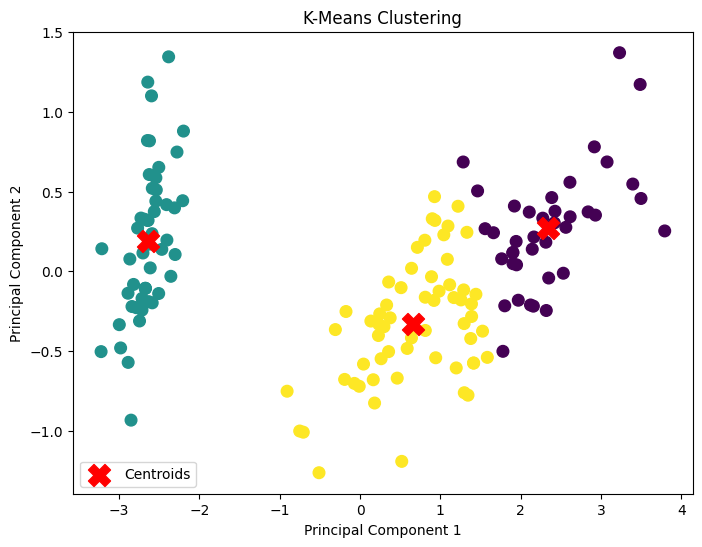

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=predicted,
    cmap='viridis',
    s=70
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

Step 8: Visualize Actual Species

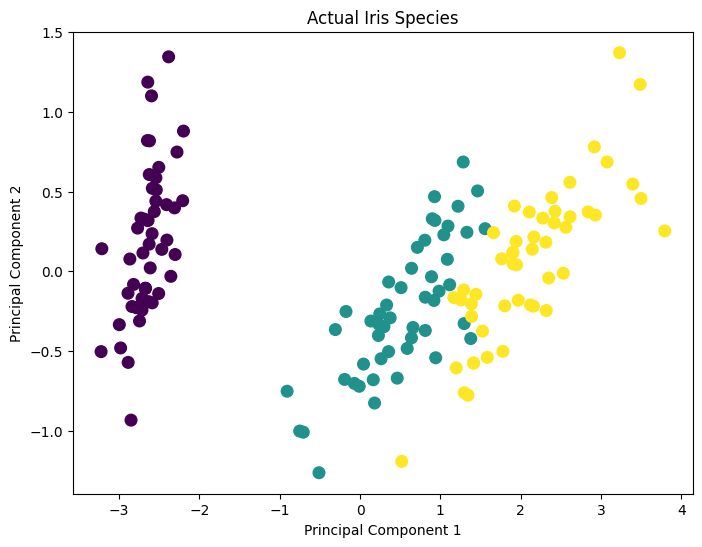

In [20]:
species_map = {
    "Iris-setosa":0,
    "Iris-versicolor":1,
    "Iris-virginica":2
}

actual = df["Species"].map(species_map)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=actual,
    cmap='viridis',
    s=70
)

plt.title("Actual Iris Species")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

Step 9: Compare Actual vs Predicted




In [21]:
comparison = pd.DataFrame({
    "Actual Species": df["Species"],
    "Predicted Cluster": predicted
})

comparison.head(20)

,Actual Species,Predicted Cluster
0,Iris-setosa,1
1,Iris-setosa,1
2,Iris-setosa,1
3,Iris-setosa,1
4,Iris-setosa,1
5,Iris-setosa,1
6,Iris-setosa,1
7,Iris-setosa,1
8,Iris-setosa,1
9,Iris-setosa,1


Step 10: Confusion Matrix

In [22]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

actual_labels = encoder.fit_transform(df["Species"])

cm = confusion_matrix(actual_labels, predicted)

print(cm)

[[ 0 50  0]
 [ 3  0 47]
 [36  0 14]]


Step 11: Explained Variance

In [23]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.92461621 0.05301557]


Step 12: Conclusion

• The Iris dataset was loaded from a CSV file.
• The Id column was removed because it does not contribute to clustering.
• PCA reduced the four numerical features into two principal components.
• K-Means (k = 3) grouped the flowers into three clusters.
• The predicted clusters were compared with the actual species labels.
• The visualization shows that Setosa is well separated, while Versicolor and Virginica have slight overlap.